In [27]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import silhouette_samples
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

In [18]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)  # atau gunakan pd.set_option('display.max_colwidth', -1) di versi lama
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

In [19]:
data = pd.read_csv("tugas5_ganjil.csv")
print("5 Baris Pertama Dataset:")
print(data.head())
print("\nInformasi Tipe Data:")
print(data.info())

5 Baris Pertama Dataset:
   ID  Age  Gender Region  Blood_Pressure  Cholesterol   BMI  Heart_Rate Exercise_Level  Smoking Alcohol_Consumption  Diabetes  Family_History  Stress_Level  Heart_Attack  Angina  Heart_Disease_History       Diet  Sleep_Hours  Occupation Income_Level Physical_Activity Education_Level Marital_Status Urban_Rural  Medication  Health_Awareness  Daily_Water_Intake  Mental_Health  Obesity
0   1   50    Male  Rural          110.00       196.50 15.90          76           High    False            Moderate     False           False             8         False   False                  False  Unhealthy         9.40  Unemployed          Low               Low         Primary        Married       Rural       False                 5                2.30              5    False
1   2   40  Female  Urban          138.80       157.50 27.10          82       Moderate    False                 NaN     False            True             5         False    True                  False  

In [20]:
data = (
    data[['BMI', 'Cholesterol']]
    .apply(pd.to_numeric, errors='coerce')
    .dropna()
)

print("\nData Setelah Penanganan Missing Values (5 Baris Pertama):")
print(data.head())


Data Setelah Penanganan Missing Values (5 Baris Pertama):
    BMI  Cholesterol
0 15.90       196.50
1 27.10       157.50
2 27.20       210.10
3 26.00       170.50
4 27.50       224.50


In [21]:
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data[['BMI', 'Cholesterol']])
data_normalized = pd.DataFrame(data_normalized, columns=['BMI', 'Cholesterol'], index=data.index)
data['BMI_normalized'] = data_normalized['BMI']
data['Cholesterol_normalized'] = data_normalized['Cholesterol']

print("\nData Setelah Normalisasi (5 Baris Pertama):")
print(data.head())


Data Setelah Normalisasi (5 Baris Pertama):
    BMI  Cholesterol  BMI_normalized  Cholesterol_normalized
0 15.90       196.50           -1.82                   -0.07
1 27.10       157.50            0.42                   -0.85
2 27.20       210.10            0.44                    0.20
3 26.00       170.50            0.20                   -0.59
4 27.50       224.50            0.50                    0.49


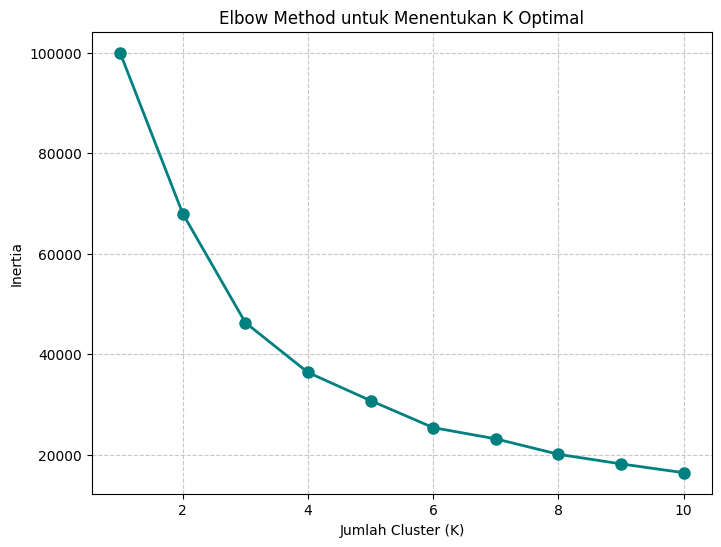

In [22]:
# Tentukan jumlah cluster optimal menggunakan Elbow Method
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(data_normalized[['BMI', 'Cholesterol']])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, 'o-', color='teal', markersize=8, linewidth=2)  # Changed to teal for softer color
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method untuk Menentukan K Optimal')
plt.grid(True, linestyle='--', alpha=0.7)  # Added grid for better readability
plt.show()

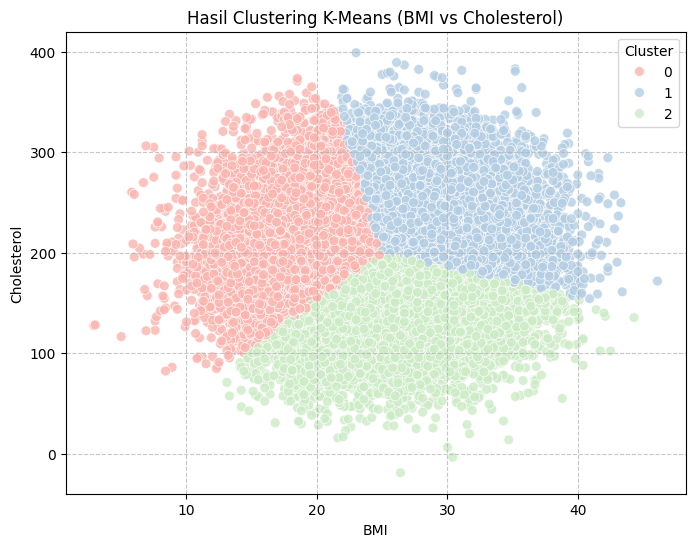

In [29]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
data_selected['KMeans_Cluster'] = kmeans.fit_predict(data_normalized[['BMI', 'Cholesterol']])

# Visualisasi hasil K-Means
plt.figure(figsize=(8, 6))
sns.scatterplot(x='BMI', y='Cholesterol', hue='KMeans_Cluster', data=data_selected,
                palette='Pastel1', s=50, alpha=0.8)  # Changed to Pastel1 for softer colors
plt.title('Hasil Clustering K-Means (BMI vs Cholesterol)')
plt.xlabel('BMI')
plt.ylabel('Cholesterol')
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

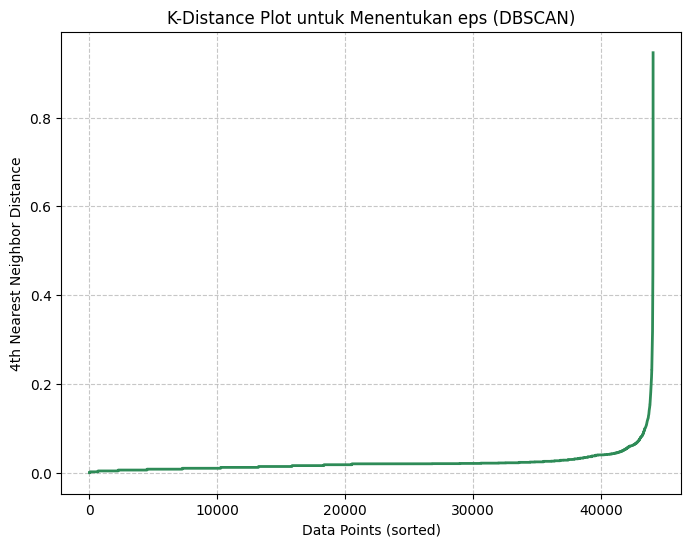

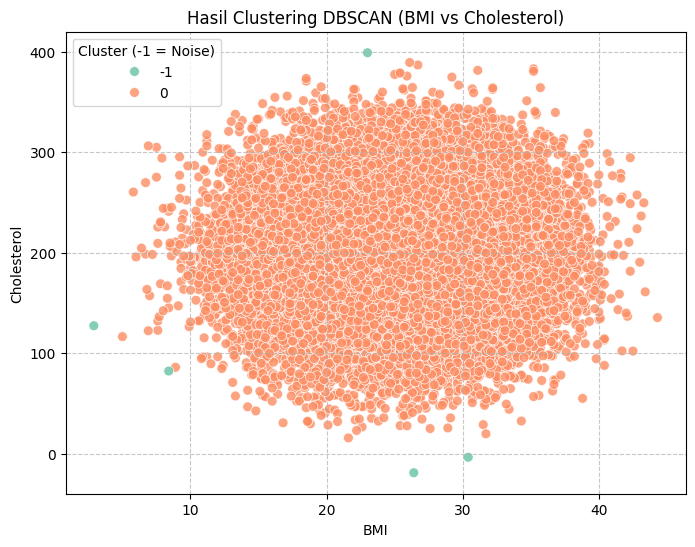

In [7]:
# Tentukan parameter DBSCAN menggunakan metode k-distance
neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(data_normalized[['BMI', 'Cholesterol']])
distances, indices = neighbors_fit.kneighbors(data_normalized[['BMI', 'Cholesterol']])

# Urutkan jarak untuk plot k-distance
distances = np.sort(distances[:, 3], axis=0)
plt.figure(figsize=(8, 6))
plt.plot(distances, color='seagreen', linewidth=2)  # Changed to seagreen for softer color
plt.xlabel('Data Points (sorted)')
plt.ylabel('4th Nearest Neighbor Distance')
plt.title('K-Distance Plot untuk Menentukan eps (DBSCAN)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Terapkan DBSCAN (misalnya, eps=0.5, min_samples=5 berdasarkan k-distance plot)
dbscan = DBSCAN(eps=0.5, min_samples=5)
data_selected['DBSCAN_Cluster'] = dbscan.fit_predict(data_normalized[['BMI', 'Cholesterol']])

# Visualisasi hasil DBSCAN
plt.figure(figsize=(8, 6))
sns.scatterplot(x='BMI', y='Cholesterol', hue='DBSCAN_Cluster', data=data_selected,
                palette='Set2', s=50, alpha=0.8)  # Changed to Set2 for softer colors
plt.title('Hasil Clustering DBSCAN (BMI vs Cholesterol)')
plt.xlabel('BMI')
plt.ylabel('Cholesterol')
plt.legend(title='Cluster (-1 = Noise)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [8]:
# Statistik DBSCAN
print("\nHasil DBSCAN:")
print(f"Jumlah Cluster (tidak termasuk noise): {len(np.unique(data_selected['DBSCAN_Cluster'][data_selected['DBSCAN_Cluster'] != -1]))}")
print(f"Jumlah Noise Points: {len(data_selected[data_selected['DBSCAN_Cluster'] == -1])}")

# Perbandingan K-Means dan DBSCAN
print("\nPerbandingan K-Means dan DBSCAN:")
print("- K-Means:")
print("  - Kelebihan: Memberikan cluster yang jelas dan mudah diinterpretasikan (3 kelompok BMI dengan kadar kolesterol berbeda). Cocok untuk data dengan distribusi merata.")
print("  - Kekurangan: Mengasumsikan cluster berbentuk bulat dan tidak bisa menangani noise. Semua data dipaksa masuk ke dalam cluster.")
print("- DBSCAN:")
print("  - Kelebihan: Dapat menangani noise (misalnya, individu dengan BMI atau kolesterol ekstrem) dan mendeteksi cluster dengan bentuk tidak beraturan.")
print("  - Kekurangan: Sensitif terhadap parameter eps dan min_samples. Jika data terlalu padat atau bervariasi, banyak poin bisa menjadi noise.")
print("- Kontekstual: K-Means lebih cocok untuk dataset ini karena distribusi data cukup merata dan kita ingin semua data dikelompokkan. DBSCAN berguna untuk mengidentifikasi outlier.")


Hasil DBSCAN:
Jumlah Cluster (tidak termasuk noise): 1
Jumlah Noise Points: 5

Perbandingan K-Means dan DBSCAN:
- K-Means:
  - Kelebihan: Memberikan cluster yang jelas dan mudah diinterpretasikan (3 kelompok BMI dengan kadar kolesterol berbeda). Cocok untuk data dengan distribusi merata.
  - Kekurangan: Mengasumsikan cluster berbentuk bulat dan tidak bisa menangani noise. Semua data dipaksa masuk ke dalam cluster.
- DBSCAN:
  - Kelebihan: Dapat menangani noise (misalnya, individu dengan BMI atau kolesterol ekstrem) dan mendeteksi cluster dengan bentuk tidak beraturan.
  - Kekurangan: Sensitif terhadap parameter eps dan min_samples. Jika data terlalu padat atau bervariasi, banyak poin bisa menjadi noise.
- Kontekstual: K-Means lebih cocok untuk dataset ini karena distribusi data cukup merata dan kita ingin semua data dikelompokkan. DBSCAN berguna untuk mengidentifikasi outlier.
